# 126 — SAB Analysis: Kmerseek Pfam Subdomain Benchmark Deep Dive

Addresses hypotheses and open questions from notebook 123:

1. **Effective window**: Does each k-size have a sweet spot of evolutionary distance? Is k=20 really optimal, or do smaller k-sizes do better at deep divergence?
2. **Why composite beats Poisson**: Is the Poisson model mis-calibrated, explaining why raw `enrichment × containment` outperforms p-value-based scores?
3. **Domain length stratification**: Are medium-length domains (50–300 aa) most detectable due to stronger functional constraints?
4. **ML classifier**: Can a trained model beat the best composite score?
5. **Operational thresholds**: What score cutoffs achieve ≥99% precision or ≥80% recall per species?

**Note on small k-size data availability** (from `kmerseek_qfo_pfam_benchmark.nf`):
The pipeline pre-filters rows with `awk '$pvalue < 0.05'` before writing `.zst` files.
At small k, k-mer saturation means enrichment ≈ 1 for closely-related species → p ≈ 1 → nothing written.
Available non-empty files:
- k=10: **no species** (complete saturation)
- k=12: **ecoli only** (2000 MYA)
- k=14: **chicken, ciona, fly, yeast, arabidopsis, ecoli** (≥300 MYA only)
- k=16,18: all 9 species
- k=20–40: all 9 species (pre-computed in notebook 123)

In [7]:
from pathlib import Path
import json
import warnings

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
pl.Config.set_tbl_rows(20)

REPO_ROOT = Path("..")
BENCHMARK_DIR = REPO_ROOT / "results/pfam_benchmark"
PAIRS_DIR = BENCHMARK_DIR / "pairs"
ANNOT_DIR = BENCHMARK_DIR / "annotations"
MERGED_DIR = BENCHMARK_DIR / "merged"
SPECIES_META = REPO_ROOT / "data/species_metadata.json"
MERGED_DIR.mkdir(exist_ok=True)
(REPO_ROOT / "figures").mkdir(exist_ok=True)

KMERSEEK_DIR = Path.home() / "data/qfo-pfam-benchmark/kmerseek-results"
ENCODING = "hp"

# k=20–40 already processed by notebook 123
# k=12,14,16,18 are new (small k, only some species have data)
KSIZES_NEW = [12, 14, 16, 18]
KSIZES_ALL = [12, 14, 16, 18, 20, 24, 28, 32, 36, 40]

with open(SPECIES_META) as f:
    META = json.load(f)

N_PROTEINS = {
    "human": 20600,
    "mouse": 21989,
    "chicken": 18116,
    "zebrafish": 25698,
    "ciona": 16678,
    "fly": 13811,
    "worm": 19819,
    "yeast": 6049,
    "arabidopsis": 27500,
    "ecoli": 4391,
}
N_HUMAN = N_PROTEINS["human"]

SPECIES_ORDER = sorted([s for s in META if s != "human"], key=lambda s: META[s]["mya"])
print("Species (MYA order):", [(s, META[s]["mya"]) for s in SPECIES_ORDER])

Species (MYA order): [('mouse', 100), ('chicken', 300), ('zebrafish', 430), ('ciona', 550), ('fly', 600), ('worm', 650), ('yeast', 900), ('arabidopsis', 1500), ('ecoli', 2000)]


In [8]:
# ── helpers (same as notebook 123) ───────────────────────────────────────────


def extract_accession_expr(col: str) -> pl.Expr:
    return (
        pl.col(col)
        .str.extract(r"(?:sp|tr)\|([A-Z0-9]+)\|", group_index=1)
        .fill_null(
            pl.col(col).str.extract(
                r"^([OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9](?:[A-Z][A-Z0-9]{2}[0-9]){1,2})",
                group_index=1,
            )
        )
    )


KS_COLS = [
    "enrichment",
    "containment",
    "jaccard",
    "query_tfidf",
    "mean_matched_kmer_freq",
    "sum_matched_kmer_freq",
    "expected_shared_kmers",
    "poisson_pvalue",
]


def add_composite_scores(df: pl.DataFrame) -> pl.DataFrame:
    eps = 1e-9
    return df.with_columns(
        [
            (
                pl.col("enrichment")
                * pl.col("containment")
                / (pl.col("mean_matched_kmer_freq") + eps)
            ).alias("score_enr_cont_freq"),
            (pl.col("enrichment") * pl.col("containment")).alias("score_enr_cont"),
            (
                -pl.col("poisson_pvalue")
                .clip(lower_bound=1e-300)
                .log(base=10)
                .fill_nan(0.0)
                * pl.col("containment")
            ).alias("score_neglogp_cont"),
            (pl.col("query_tfidf") * pl.col("containment")).alias("score_tfidf_cont"),
            (
                -pl.col("poisson_pvalue")
                .clip(lower_bound=1e-300)
                .log(base=10)
                .fill_nan(0.0)
            ).alias("score_neglogp"),
            (
                -pl.col("bonf_pvalue")
                .clip(lower_bound=1e-300)
                .log(base=10)
                .fill_nan(0.0)
            ).alias("score_bonf_neglogp"),
            (
                -pl.col("bonf_pvalue")
                .clip(lower_bound=1e-300)
                .log(base=10)
                .fill_nan(0.0)
                * pl.col("containment")
            ).alias("score_bonf_neglogp_cont"),
            (
                -pl.col("bh_pvalue").clip(lower_bound=1e-300).log(base=10).fill_nan(0.0)
            ).alias("score_bh_neglogq"),
            (
                -pl.col("bh_pvalue").clip(lower_bound=1e-300).log(base=10).fill_nan(0.0)
                * pl.col("containment")
            ).alias("score_bh_neglogq_cont"),
        ]
    )


SCORE_COLS = [
    "score_enr_cont_freq",
    "score_enr_cont",
    "score_neglogp_cont",
    "score_tfidf_cont",
    "score_neglogp",
    "score_bonf_neglogp",
    "score_bonf_neglogp_cont",
    "score_bh_neglogq",
    "score_bh_neglogq_cont",
    "enrichment",
    "containment",
    "jaccard",
]
SCORE_LABELS = {
    "score_enr_cont_freq": "enr × cont / freq  ★",
    "score_enr_cont": "enr × cont",
    "score_neglogp_cont": "-log p × cont",
    "score_tfidf_cont": "tfidf × cont",
    "score_neglogp": "-log p (raw)",
    "score_bonf_neglogp": "-log(p·N_bonf)",
    "score_bonf_neglogp_cont": "-log(p·N_bonf) × cont",
    "score_bh_neglogq": "-log q_BH",
    "score_bh_neglogq_cont": "-log q_BH × cont",
    "enrichment": "enrichment",
    "containment": "containment",
    "jaccard": "jaccard",
}
BEST_SCORE = "score_enr_cont_freq"


def load_and_merge(species: str, ksize: int) -> pl.DataFrame | None:
    gt_path = PAIRS_DIR / f"human_vs_{species}_ground_truth.parquet"
    if not gt_path.exists():
        return None

    # Try .gz first (k>=20), then .zst (k<20)
    csv_path = None
    for ext in ["gz", "zst"]:
        p = KMERSEEK_DIR / f"human_vs_{species}.{ENCODING}.k{ksize}.results.csv.{ext}"
        if p.exists() and p.stat().st_size > 100:
            csv_path = p
            break

    gt = pl.read_parquet(gt_path)
    n_bonf = float(N_HUMAN * N_PROTEINS.get(species, 10_000))

    if csv_path is not None:
        # quote_char=None: accession names like "tr|P12345|..." contain literal
        # double-quotes that polars misinterprets as CSV quoting delimiters
        ks_df = pl.scan_csv(csv_path, quote_char=None, ignore_errors=True).collect()
        ks_df = ks_df.with_columns(
            [
                extract_accession_expr("query_name").alias("human_accession"),
                extract_accession_expr("target_name").alias("species_accession"),
            ]
        )
        merged = gt.join(
            ks_df.select(["human_accession", "species_accession"] + KS_COLS),
            on=["human_accession", "species_accession"],
            how="left",
        )
    else:
        # No kmerseek hits for this (species, ksize) — fill with nulls
        merged = gt.with_columns(
            [pl.lit(None).cast(pl.Float64).alias(c) for c in KS_COLS]
        )

    merged = merged.with_columns(
        [pl.col("poisson_pvalue").fill_null(1.0)]
        + [pl.col(c).fill_null(0.0) for c in KS_COLS if c != "poisson_pvalue"]
        + [
            pl.lit(species).alias("species"),
            pl.lit(META[species]["mya"]).alias("mya"),
            pl.lit(ksize).alias("ksize"),
        ]
    )
    merged = merged.with_columns(
        [
            (pl.col("poisson_pvalue") * n_bonf)
            .clip(upper_bound=1.0)
            .alias("bonf_pvalue"),
            (
                pl.col("poisson_pvalue")
                * n_bonf
                / pl.col("poisson_pvalue").rank("ordinal")
            )
            .clip(upper_bound=1.0)
            .alias("bh_pvalue"),
        ]
    )
    return add_composite_scores(merged)


def compute_aucs(df: pl.DataFrame) -> dict:
    y = df["label"].cast(pl.Int8).to_numpy()
    if y.sum() == 0 or (1 - y).sum() == 0:
        return {}
    out = {}
    for col in SCORE_COLS:
        if col not in df.columns:
            continue
        scores = df[col].fill_null(0.0).fill_nan(0.0).to_numpy()
        try:
            out[col] = {
                "roc_auc": roc_auc_score(y, scores),
                "pr_auc": average_precision_score(y, scores),
            }
        except Exception:
            pass
    return out


print("Helpers defined.")

Helpers defined.


In [10]:
# Process new k-sizes (k=12,14,16,18) — skip if already cached as parquet
# NOTE: ecoli k=14 (~805 MB compressed) and yeast k=14 (~306 MB) take several minutes each.

for ksize in KSIZES_NEW:
    for sp in SPECIES_ORDER:
        out = MERGED_DIR / f"human_vs_{sp}.hp.k{ksize}.merged.parquet"
        if out.exists():
            print(f"  [cache] {sp} k{ksize}")
            continue
        df = load_and_merge(sp, ksize)
        if df is not None:
            df.write_parquet(out, compression="snappy")
            n_hit = int((df["containment"] > 0).sum())
            pct = 100 * n_hit / len(df)
            print(
                f"  [new]   {sp} k{ksize}: {len(df):,} pairs, {n_hit:,} hits ({pct:.1f}%)"
            )
        else:
            print(f"  [skip]  {sp} k{ksize} — no ground truth")

print("Done.")

  [cache] mouse k12
  [cache] chicken k12
  [cache] zebrafish k12
  [cache] ciona k12
  [cache] fly k12
  [cache] worm k12
  [cache] yeast k12
  [cache] arabidopsis k12
  [cache] ecoli k12
  [cache] mouse k14
  [cache] chicken k14
  [cache] zebrafish k14
  [cache] ciona k14
  [cache] fly k14
  [cache] worm k14
  [cache] yeast k14
  [cache] arabidopsis k14
  [cache] ecoli k14
  [cache] mouse k16
  [cache] chicken k16
  [cache] zebrafish k16
  [cache] ciona k16
  [cache] fly k16
  [cache] worm k16
  [cache] yeast k16
  [cache] arabidopsis k16
  [cache] ecoli k16
  [cache] mouse k18
  [cache] chicken k18
  [cache] zebrafish k18
  [cache] ciona k18
  [cache] fly k18
  [cache] worm k18
  [cache] yeast k18
  [cache] arabidopsis k18
  [cache] ecoli k18
Done.


In [13]:
# Load ALL merged parquets
all_merged: dict[tuple, pl.DataFrame] = {}

for ksize in KSIZES_ALL:
    for sp in SPECIES_ORDER:
        p = MERGED_DIR / f"human_vs_{sp}.hp.k{ksize}.merged.parquet"
        if p.exists():
            all_merged[(sp, ksize)] = pl.read_parquet(p)

print(f"Loaded {len(all_merged)} (species, ksize) combinations")
print("K-sizes present:", sorted({k for _, k in all_merged}))

# Show which (species, ksize) pairs have actual hits vs all-zero
coverage = pl.DataFrame(
    [
        {
            "species": sp,
            "mya": META[sp]["mya"],
            "ksize": k,
            "n_pairs": len(df),
            "n_hit": int((df["containment"] > 0).sum()),
            "hit_pct": round(100 * (df["containment"] > 0).mean(), 1),
        }
        for (sp, k), df in all_merged.items()
    ]
).sort(["mya", "ksize"])

print("\nCoverage matrix (hit %):")
print(
    coverage.pivot(on="ksize", index=["species", "mya"], values="hit_pct").sort("mya")
)

Loaded 90 (species, ksize) combinations
K-sizes present: [12, 14, 16, 18, 20, 24, 28, 32, 36, 40]

Coverage matrix (hit %):
shape: (9, 12)
┌─────────────┬──────┬─────┬─────┬───┬──────┬──────┬─────┬─────┐
│ species     ┆ mya  ┆ 12  ┆ 14  ┆ … ┆ 28   ┆ 32   ┆ 36  ┆ 40  │
│ ---         ┆ ---  ┆ --- ┆ --- ┆   ┆ ---  ┆ ---  ┆ --- ┆ --- │
│ str         ┆ i64  ┆ f64 ┆ f64 ┆   ┆ f64  ┆ f64  ┆ f64 ┆ f64 │
╞═════════════╪══════╪═════╪═════╪═══╪══════╪══════╪═════╪═════╡
│ mouse       ┆ 100  ┆ 0.0 ┆ 0.0 ┆ … ┆ 12.6 ┆ 10.3 ┆ 8.9 ┆ 7.7 │
│ chicken     ┆ 300  ┆ 0.0 ┆ 0.0 ┆ … ┆ 9.0  ┆ 6.6  ┆ 5.7 ┆ 4.7 │
│ zebrafish   ┆ 430  ┆ 0.0 ┆ 0.0 ┆ … ┆ 9.0  ┆ 6.7  ┆ 5.1 ┆ 3.9 │
│ ciona       ┆ 550  ┆ 0.0 ┆ 0.0 ┆ … ┆ 2.9  ┆ 1.9  ┆ 1.9 ┆ 0.9 │
│ fly         ┆ 600  ┆ 0.0 ┆ 0.0 ┆ … ┆ 3.1  ┆ 1.8  ┆ 5.5 ┆ 0.8 │
│ worm        ┆ 650  ┆ 0.0 ┆ 0.0 ┆ … ┆ 2.1  ┆ 1.0  ┆ 0.9 ┆ 0.5 │
│ yeast       ┆ 900  ┆ 0.0 ┆ 0.0 ┆ … ┆ 1.2  ┆ 0.4  ┆ 0.5 ┆ 0.2 │
│ arabidopsis ┆ 1500 ┆ 0.0 ┆ 0.0 ┆ … ┆ 1.2  ┆ 0.6  ┆ 0.3 ┆ 0.2 │
│ ecoli       ┆ 

In [14]:
# Compute AUC for all (species, ksize, score_col) — cache result

AUC_SCHEMA = {
    "species": pl.Utf8,
    "mya": pl.Int64,
    "ksize": pl.Int64,
    "score_col": pl.Utf8,
    "roc_auc": pl.Float64,
    "pr_auc": pl.Float64,
}
auc_path = MERGED_DIR / "auc_by_species_ksize_score_extended.parquet"

if auc_path.exists():
    auc_df = pl.read_parquet(auc_path)
    # If new k-sizes are missing, recompute
    existing_ks = set(auc_df["ksize"].unique().to_list())
    if not set(KSIZES_NEW).issubset(existing_ks):
        print(f"Cache missing k-sizes {set(KSIZES_NEW) - existing_ks}, recomputing...")
        auc_path.unlink()

if not auc_path.exists():
    auc_records = []
    for (sp, ksize), df in all_merged.items():
        for score_col, vals in compute_aucs(df).items():
            auc_records.append(
                {
                    "species": sp,
                    "mya": META[sp]["mya"],
                    "ksize": ksize,
                    "score_col": score_col,
                    "roc_auc": vals["roc_auc"],
                    "pr_auc": vals["pr_auc"],
                }
            )
    auc_df = (
        pl.DataFrame(auc_records, schema=AUC_SCHEMA)
        if auc_records
        else pl.DataFrame(schema=AUC_SCHEMA)
    )
    auc_df.write_parquet(auc_path, compression="snappy")
    print(f"Computed {len(auc_df)} AUC rows and cached.")
else:
    print(f"Loaded cached AUC table: {len(auc_df)} rows")

auc_df.head(6)

Computed 1080 AUC rows and cached.


species,mya,ksize,score_col,roc_auc,pr_auc
str,i64,i64,str,f64,f64
"""mouse""",100,12,"""score_enr_cont_freq""",0.5,0.333333
"""mouse""",100,12,"""score_enr_cont""",0.5,0.333333
"""mouse""",100,12,"""score_neglogp_cont""",0.5,0.333333
"""mouse""",100,12,"""score_tfidf_cont""",0.5,0.333333
"""mouse""",100,12,"""score_neglogp""",0.5,0.333333
"""mouse""",100,12,"""score_bonf_neglogp""",0.5,0.333333


---
## Section 1: Effective Window Hypothesis

**Claim**: Each k-size has an effective evolutionary window. k=20 maximizes this window.

**Key context**: At small k, the Poisson filter (p<0.05) removes all hits for closely-related species because k-mer saturation makes enrichment ≈ 1 → this is why k=12 only has ecoli, k=14 only has species ≥300 MYA.

**Tests**:
- ROC-AUC and hit rate vs MYA for all available k-sizes
- Best k-size per species
- Two-sided window: large k → sparse signal at distance; small k → saturation near relatives

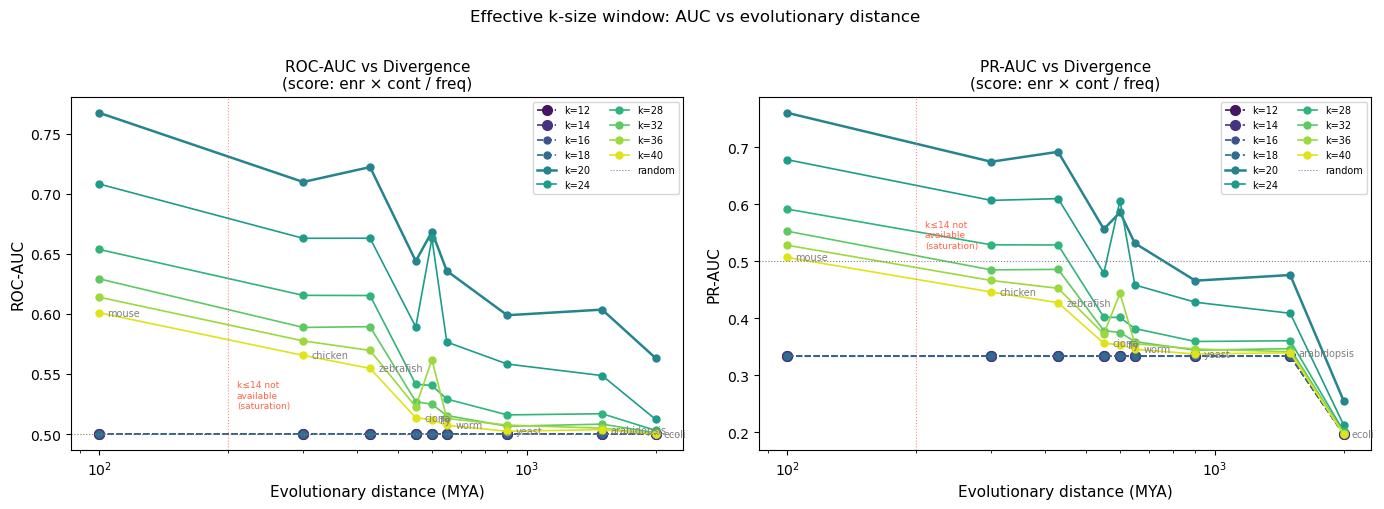

In [15]:
best_auc = auc_df.filter(pl.col("score_col") == BEST_SCORE).sort(["ksize", "mya"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cmap = plt.cm.viridis
colors = cmap(np.linspace(0.05, 0.95, len(KSIZES_ALL)))

for metric, ax in zip(["roc_auc", "pr_auc"], axes):
    for ksize, color in zip(KSIZES_ALL, colors):
        sub = best_auc.filter(pl.col("ksize") == ksize).sort("mya")
        if sub.is_empty():
            continue
        ls = "-" if ksize >= 20 else "--"
        ax.plot(
            sub["mya"].to_numpy(),
            sub[metric].to_numpy(),
            "o" + ls,
            color=color,
            label=f"k={ksize}",
            linewidth=1.8 if ksize == 20 else 1.2,
            markersize=5 if ksize >= 16 else 7,
        )

    ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.8, label="random")
    ax.set_xlabel("Evolutionary distance (MYA)", fontsize=11)
    ax.set_ylabel(metric.replace("_", "-").upper(), fontsize=11)
    ax.set_xscale("log")
    ax.set_title(
        f'{metric.replace("_","-").upper()} vs Divergence\n(score: enr × cont / freq)',
        fontsize=11,
    )
    ax.legend(fontsize=7, ncol=2, loc="upper right")

    # Annotate species on the k=40 line
    for row in best_auc.filter(pl.col("ksize") == 40).sort("mya").iter_rows(named=True):
        ax.annotate(
            row["species"],
            xy=(row["mya"], row[metric]),
            xytext=(6, 0),
            textcoords="offset points",
            fontsize=7,
            va="center",
            color="gray",
        )

    # Shade "small k only" region (species absent from k<16 due to saturation)
    ax.axvline(200, color="tomato", linestyle=":", linewidth=0.8, alpha=0.7)
    ax.text(
        210,
        0.52,
        "k≤14 not\navailable\n(saturation)",
        fontsize=6.5,
        color="tomato",
        va="bottom",
    )

plt.suptitle(
    "Effective k-size window: AUC vs evolutionary distance", fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig("../figures/126_ksize_window_auc_vs_mya.png", dpi=150, bbox_inches="tight")
plt.show()

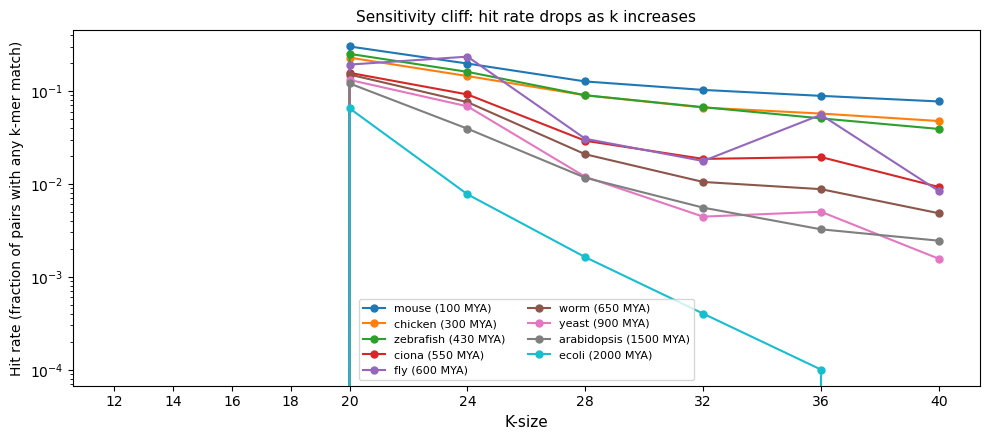

In [16]:
# Hit rate vs k-size per species — shows sensitivity cliff
fig, ax = plt.subplots(figsize=(10, 4.5))
sp_colors = plt.cm.tab10(np.linspace(0, 0.9, len(SPECIES_ORDER)))

for sp, color in zip(SPECIES_ORDER, sp_colors):
    rows = [
        (k, (df["containment"] > 0).mean())
        for (s, k), df in all_merged.items()
        if s == sp
    ]
    if not rows:
        continue
    rows.sort()
    ks, hrs = zip(*rows)
    ax.plot(
        ks,
        hrs,
        "o-",
        color=color,
        label=f"{sp} ({META[sp]['mya']} MYA)",
        linewidth=1.5,
        markersize=5,
    )

ax.set_xlabel("K-size", fontsize=11)
ax.set_ylabel("Hit rate (fraction of pairs with any k-mer match)", fontsize=10)
ax.set_title("Sensitivity cliff: hit rate drops as k increases", fontsize=11)
ax.set_yscale("log")
ax.legend(fontsize=8, ncol=2)
ax.set_xticks(KSIZES_ALL)
plt.tight_layout()
plt.savefig("../figures/126_hit_rate_vs_ksize.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# Best k-size per species and the two-sided window summary
best_k_rows = []
for sp in SPECIES_ORDER:
    sp_aucs = best_auc.filter(pl.col("species") == sp)
    if sp_aucs.is_empty():
        continue
    best_row = sp_aucs.sort("roc_auc", descending=True).head(1)
    best_k_rows.append(
        {
            "species": sp,
            "mya": META[sp]["mya"],
            "best_ksize": best_row["ksize"].item(),
            "best_roc_auc": round(best_row["roc_auc"].item(), 4),
            "k20_roc_auc": round(
                (
                    sp_aucs.filter(pl.col("ksize") == 20)["roc_auc"].item()
                    if not sp_aucs.filter(pl.col("ksize") == 20).is_empty()
                    else float("nan")
                ),
                4,
            ),
        }
    )

best_k_df = pl.DataFrame(best_k_rows)
best_k_df = best_k_df.with_columns(
    (pl.col("best_roc_auc") - pl.col("k20_roc_auc")).alias("improvement_over_k20")
)
print("Best k-size per species (using score_enr_cont_freq):")
print(best_k_df)

Best k-size per species (using score_enr_cont_freq):
shape: (9, 6)
┌─────────────┬──────┬────────────┬──────────────┬─────────────┬──────────────────────┐
│ species     ┆ mya  ┆ best_ksize ┆ best_roc_auc ┆ k20_roc_auc ┆ improvement_over_k20 │
│ ---         ┆ ---  ┆ ---        ┆ ---          ┆ ---         ┆ ---                  │
│ str         ┆ i64  ┆ i64        ┆ f64          ┆ f64         ┆ f64                  │
╞═════════════╪══════╪════════════╪══════════════╪═════════════╪══════════════════════╡
│ mouse       ┆ 100  ┆ 20         ┆ 0.7673       ┆ 0.7673      ┆ 0.0                  │
│ chicken     ┆ 300  ┆ 20         ┆ 0.7097       ┆ 0.7097      ┆ 0.0                  │
│ zebrafish   ┆ 430  ┆ 20         ┆ 0.7221       ┆ 0.7221      ┆ 0.0                  │
│ ciona       ┆ 550  ┆ 20         ┆ 0.6439       ┆ 0.6439      ┆ 0.0                  │
│ fly         ┆ 600  ┆ 20         ┆ 0.6684       ┆ 0.6684      ┆ 0.0                  │
│ worm        ┆ 650  ┆ 20         ┆ 0.6358       ┆ 0.

---
## Section 2: Why Composite Scores Beat Poisson — Calibration Analysis

**Claim**: The Poisson model mis-calibrates p-values at k-mer saturation regimes; Bonferroni corrections collapse to 0 for essentially all pairs.

**Tests**:
1. QQ-plot of raw Poisson p-values for null (non-hit) pairs — should be uniform(0,1) if calibrated
2. Fraction of pairs where Bonferroni correction collapses p→1 (score=0), including true positives
3. AUC heatmap: all scoring methods × species at k=20

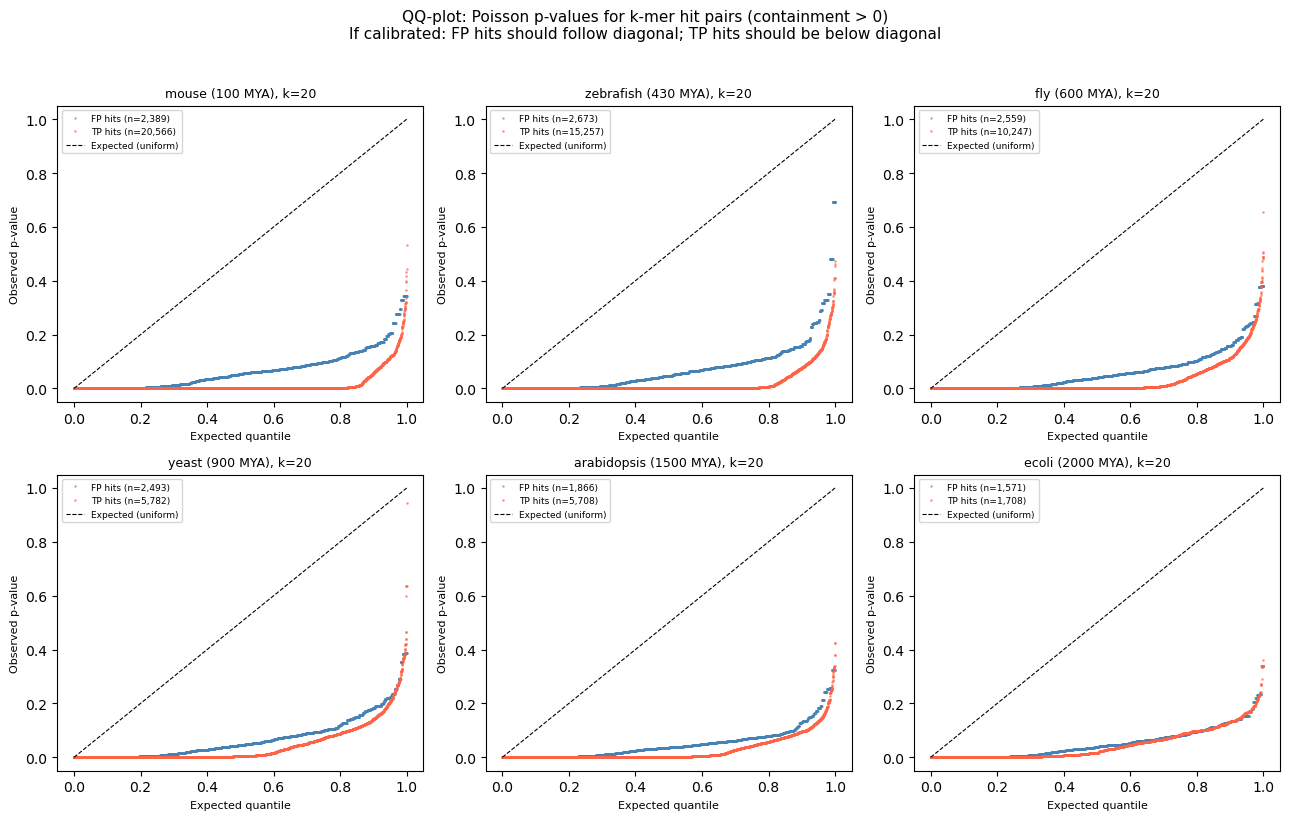

In [18]:
# 2a. QQ-plot of Poisson p-values at k=20
# Null distribution (calibration check): TN pairs with containment=0 should have p=1.0 always
# More interesting: pairs WITH containment>0 — are their p-values over-conservative?

np.random.seed(42)
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

example_species = ["mouse", "zebrafish", "fly", "yeast", "arabidopsis", "ecoli"]

for ax, sp in zip(axes, example_species):
    key = (sp, 20)
    if key not in all_merged:
        ax.set_visible(False)
        continue
    df = all_merged[key]

    # Hits only (containment > 0) — these are the pairs that passed kmerseek's filter
    hit_df = df.filter(pl.col("containment") > 0)
    tn_p = hit_df.filter(pl.col("label") == False)["poisson_pvalue"].to_numpy()
    tp_p = hit_df.filter(pl.col("label") == True)["poisson_pvalue"].to_numpy()

    n = min(len(tn_p), 3000)
    if n > 0:
        tn_sample = np.sort(np.random.choice(tn_p, n, replace=False))
        uniform = np.linspace(0, 1, n)
        ax.plot(
            uniform,
            tn_sample,
            ".",
            markersize=2,
            alpha=0.4,
            color="steelblue",
            label=f"FP hits (n={len(tn_p):,})",
        )

    n_tp = min(len(tp_p), 3000)
    if n_tp > 0:
        tp_sample = np.sort(np.random.choice(tp_p, n_tp, replace=False))
        ax.plot(
            np.linspace(0, 1, n_tp),
            tp_sample,
            ".",
            markersize=2,
            alpha=0.5,
            color="tomato",
            label=f"TP hits (n={len(tp_p):,})",
        )

    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Expected (uniform)")
    ax.set_title(f"{sp} ({META[sp]['mya']} MYA), k=20", fontsize=9)
    ax.set_xlabel("Expected quantile", fontsize=8)
    ax.set_ylabel("Observed p-value", fontsize=8)
    ax.legend(fontsize=6.5)

plt.suptitle(
    "QQ-plot: Poisson p-values for k-mer hit pairs (containment > 0)\n"
    "If calibrated: FP hits should follow diagonal; TP hits should be below diagonal",
    y=1.02,
    fontsize=11,
)
plt.tight_layout()
plt.savefig("../figures/126_poisson_calibration_qq.png", dpi=150, bbox_inches="tight")
plt.show()

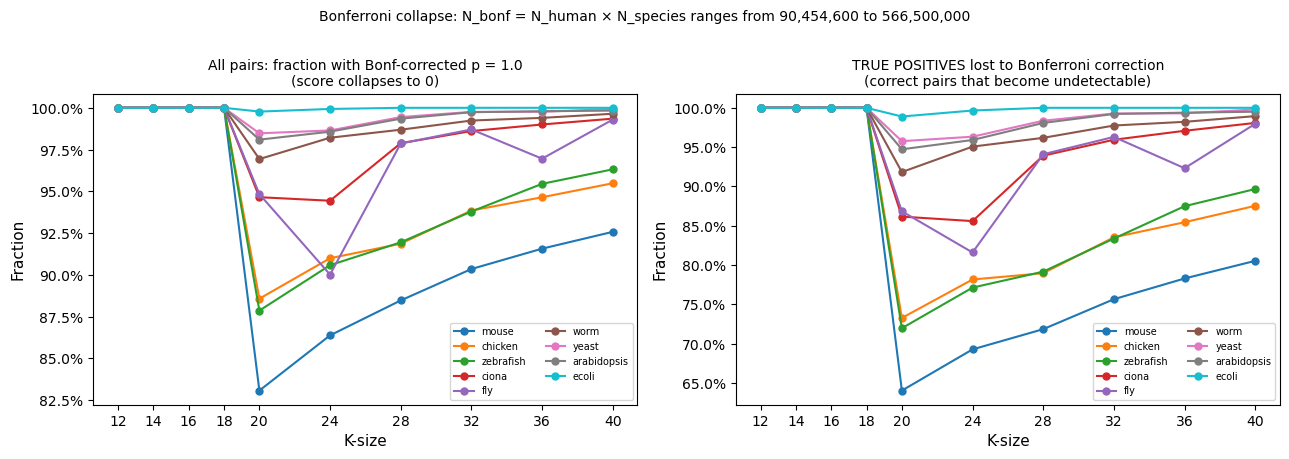

Fraction of TRUE POSITIVES lost at k=20:
shape: (9, 4)
┌─────────────┬──────┬───────────┬──────────────┐
│ species     ┆ mya  ┆ n_bonf    ┆ frac_tp_lost │
│ ---         ┆ ---  ┆ ---       ┆ ---          │
│ str         ┆ i64  ┆ i64       ┆ f64          │
╞═════════════╪══════╪═══════════╪══════════════╡
│ mouse       ┆ 100  ┆ 452973400 ┆ 0.64034      │
│ chicken     ┆ 300  ┆ 373189600 ┆ 0.732722     │
│ zebrafish   ┆ 430  ┆ 529378800 ┆ 0.719679     │
│ ciona       ┆ 550  ┆ 343566800 ┆ 0.861608     │
│ fly         ┆ 600  ┆ 284506600 ┆ 0.868411     │
│ worm        ┆ 650  ┆ 408271400 ┆ 0.918284     │
│ yeast       ┆ 900  ┆ 124609400 ┆ 0.957564     │
│ arabidopsis ┆ 1500 ┆ 566500000 ┆ 0.947229     │
│ ecoli       ┆ 2000 ┆ 90454600  ┆ 0.988936     │
└─────────────┴──────┴───────────┴──────────────┘


In [19]:
# 2b. Bonferroni collapse: fraction of pairs (and TPs) where bonf_p >= 1.0 (score = 0)

bonf_rows = []
for (sp, ksize), df in all_merged.items():
    n_total = len(df)
    n_tp = int(df["label"].sum())
    n_bonf1 = int((df["bonf_pvalue"] >= 1.0).sum())
    n_tp_bonf1 = int((df.filter(pl.col("label") == True)["bonf_pvalue"] >= 1.0).sum())
    bonf_rows.append(
        {
            "species": sp,
            "mya": META[sp]["mya"],
            "ksize": ksize,
            "n_bonf": N_HUMAN * N_PROTEINS.get(sp, 10_000),
            "frac_all_lost": n_bonf1 / n_total,
            "frac_tp_lost": n_tp_bonf1 / n_tp if n_tp > 0 else 0,
        }
    )
bonf_df = pl.DataFrame(bonf_rows).sort(["mya", "ksize"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col, title in zip(
    axes,
    ["frac_all_lost", "frac_tp_lost"],
    [
        "All pairs: fraction with Bonf-corrected p = 1.0\n(score collapses to 0)",
        "TRUE POSITIVES lost to Bonferroni correction\n(correct pairs that become undetectable)",
    ],
):
    for sp, color in zip(SPECIES_ORDER, sp_colors):
        sub = bonf_df.filter(pl.col("species") == sp).sort("ksize")
        if sub.is_empty():
            continue
        ax.plot(
            sub["ksize"].to_numpy(),
            sub[col].to_numpy(),
            "o-",
            color=color,
            label=sp,
            linewidth=1.5,
            markersize=5,
        )
    ax.set_xlabel("K-size", fontsize=11)
    ax.set_ylabel("Fraction", fontsize=11)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7, ncol=2)
    ax.set_xticks(KSIZES_ALL)

plt.suptitle(
    f"Bonferroni collapse: N_bonf = N_human × N_species ranges from "
    f'{min(bonf_df["n_bonf"].to_list()):,.0f} to {max(bonf_df["n_bonf"].to_list()):,.0f}',
    fontsize=10,
    y=1.01,
)
plt.tight_layout()
plt.savefig("../figures/126_bonferroni_collapse.png", dpi=150, bbox_inches="tight")
plt.show()

# Print worst cases
print("Fraction of TRUE POSITIVES lost at k=20:")
print(
    bonf_df.filter(pl.col("ksize") == 20)
    .select(["species", "mya", "n_bonf", "frac_tp_lost"])
    .sort("mya")
)

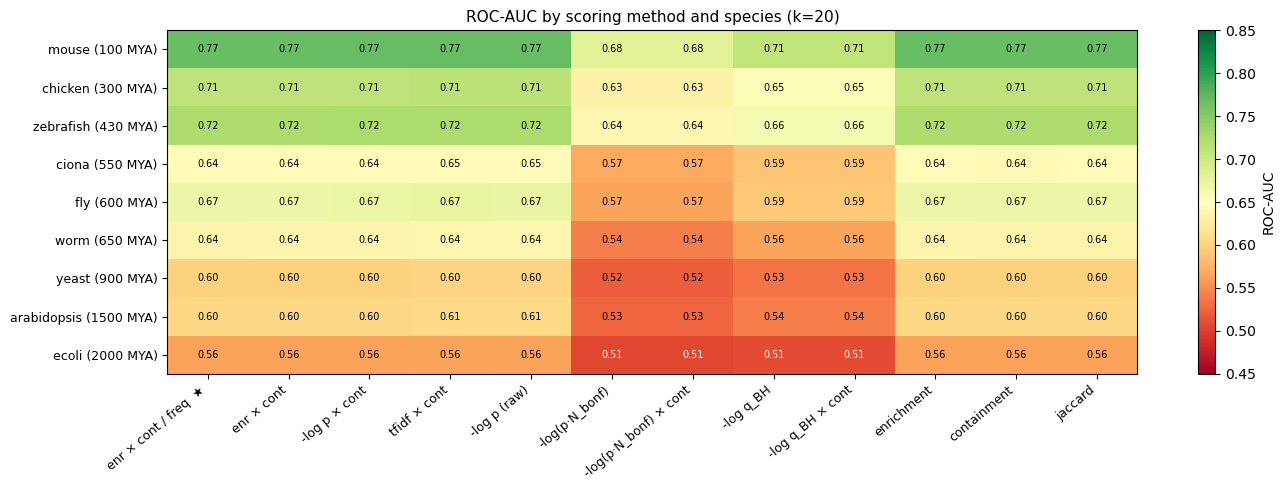

In [20]:
# 2c. AUC heatmap: all scoring methods × species at k=20
ksize = 20
sp_ordered = SPECIES_ORDER

mat = np.array(
    [
        [
            (
                auc_df.filter(
                    (pl.col("species") == sp)
                    & (pl.col("ksize") == ksize)
                    & (pl.col("score_col") == sc)
                )["roc_auc"].item()
                if not auc_df.filter(
                    (pl.col("species") == sp)
                    & (pl.col("ksize") == ksize)
                    & (pl.col("score_col") == sc)
                ).is_empty()
                else np.nan
            )
            for sc in SCORE_COLS
        ]
        for sp in sp_ordered
    ]
)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(mat, aspect="auto", cmap="RdYlGn", vmin=0.45, vmax=0.85)
ax.set_xticks(range(len(SCORE_COLS)))
ax.set_xticklabels(
    [SCORE_LABELS[s] for s in SCORE_COLS], rotation=40, ha="right", fontsize=9
)
ax.set_yticks(range(len(sp_ordered)))
ax.set_yticklabels([f"{sp} ({META[sp]['mya']} MYA)" for sp in sp_ordered], fontsize=9)
plt.colorbar(im, ax=ax, label="ROC-AUC")
ax.set_title(f"ROC-AUC by scoring method and species (k={ksize})", fontsize=11)

for i in range(len(sp_ordered)):
    for j in range(len(SCORE_COLS)):
        v = mat[i, j]
        if not np.isnan(v):
            ax.text(
                j,
                i,
                f"{v:.2f}",
                ha="center",
                va="center",
                fontsize=7,
                color="black" if 0.52 < v < 0.78 else "white",
            )

plt.tight_layout()
plt.savefig("../figures/126_score_method_auc_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 3: Domain Length Stratification

**Claim**: Medium-length domains (100–300 aa) are most detectable because they contain enough k-mers for statistical signal while being short enough to avoid accumulating neutral substitutions.

**Test**: Join with Pfam domain lengths → compute AUC and hit rate by domain length bin.

In [21]:
# Protein length stratification
# NOTE: Pfam domain position data is unavailable in human_pfam_domains.parquet
# (has_position=False for all rows, domain_length all null).
# We stratify by human_protein_length instead, which is already in every merged parquet.
# Short proteins tend to be single-domain; long proteins are multi-domain.


BIN_ORDER = ["<200 aa", "200–500 aa", "500–1000 aa", ">1000 aa"]
BIN_BOUNDS = [(0, 200), (200, 500), (500, 1000), (1000, 99999)]

# Verify coverage
sample = all_merged[("mouse", 20)]
print(
    "human_protein_length range:",
    sample["human_protein_length"].min(),
    "–",
    sample["human_protein_length"].max(),
)
print("Bin counts (mouse k=20):")
for name, (lo, hi) in zip(BIN_ORDER, BIN_BOUNDS):
    n = sample.filter(
        (pl.col("human_protein_length") >= lo) & (pl.col("human_protein_length") < hi)
    ).height
    print(f"  {name}: {n:,} pairs")

human_protein_length range: 33 – 34350
Bin counts (mouse k=20):
  <200 aa: 6,536 pairs
  200–500 aa: 24,944 pairs
  500–1000 aa: 25,502 pairs
  >1000 aa: 19,351 pairs


In [22]:
# Compute AUC and hit rate stratified by protein length bin
domain_rows = []

for ksize in [16, 20, 28, 40]:
    for sp in SPECIES_ORDER:
        key = (sp, ksize)
        if key not in all_merged:
            continue
        df = all_merged[key]
        for bin_name, (lo, hi) in zip(BIN_ORDER, BIN_BOUNDS):
            sub = df.filter(
                (pl.col("human_protein_length") >= lo)
                & (pl.col("human_protein_length") < hi)
            )
            if sub.is_empty() or int(sub["label"].sum()) < 5:
                continue
            y = sub["label"].cast(pl.Int8).to_numpy()
            scores = sub[BEST_SCORE].fill_null(0).fill_nan(0).to_numpy()
            n_hit = int((sub["containment"] > 0).sum())
            try:
                roc = roc_auc_score(y, scores)
                pr = average_precision_score(y, scores)
            except Exception:
                continue
            domain_rows.append(
                {
                    "species": sp,
                    "mya": META[sp]["mya"],
                    "ksize": ksize,
                    "domain_bin": bin_name,
                    "n_pairs": len(sub),
                    "n_pos": int(y.sum()),
                    "n_hit": n_hit,
                    "hit_rate": n_hit / len(sub),
                    "roc_auc": roc,
                    "pr_auc": pr,
                }
            )

domain_df = pl.DataFrame(domain_rows)
print(f"{len(domain_df)} rows computed")
domain_df.head(8)

144 rows computed


species,mya,ksize,domain_bin,n_pairs,n_pos,n_hit,hit_rate,roc_auc,pr_auc
str,i64,i64,str,i64,i64,i64,f64,f64,f64
"""mouse""",100,16,"""<200 aa""",6461,773,0,0.0,0.5,0.119641
"""mouse""",100,16,"""200–500 aa""",22849,5845,0,0.0,0.5,0.25581
"""mouse""",100,16,"""500–1000 aa""",20668,7831,0,0.0,0.5,0.378895
"""mouse""",100,16,""">1000 aa""",10022,5551,0,0.0,0.5,0.553881
"""chicken""",300,16,"""<200 aa""",7633,841,0,0.0,0.5,0.110179
"""chicken""",300,16,"""200–500 aa""",22732,6160,0,0.0,0.5,0.270984
"""chicken""",300,16,"""500–1000 aa""",19467,8009,0,0.0,0.5,0.411414
"""chicken""",300,16,""">1000 aa""",10168,4990,0,0.0,0.5,0.490755


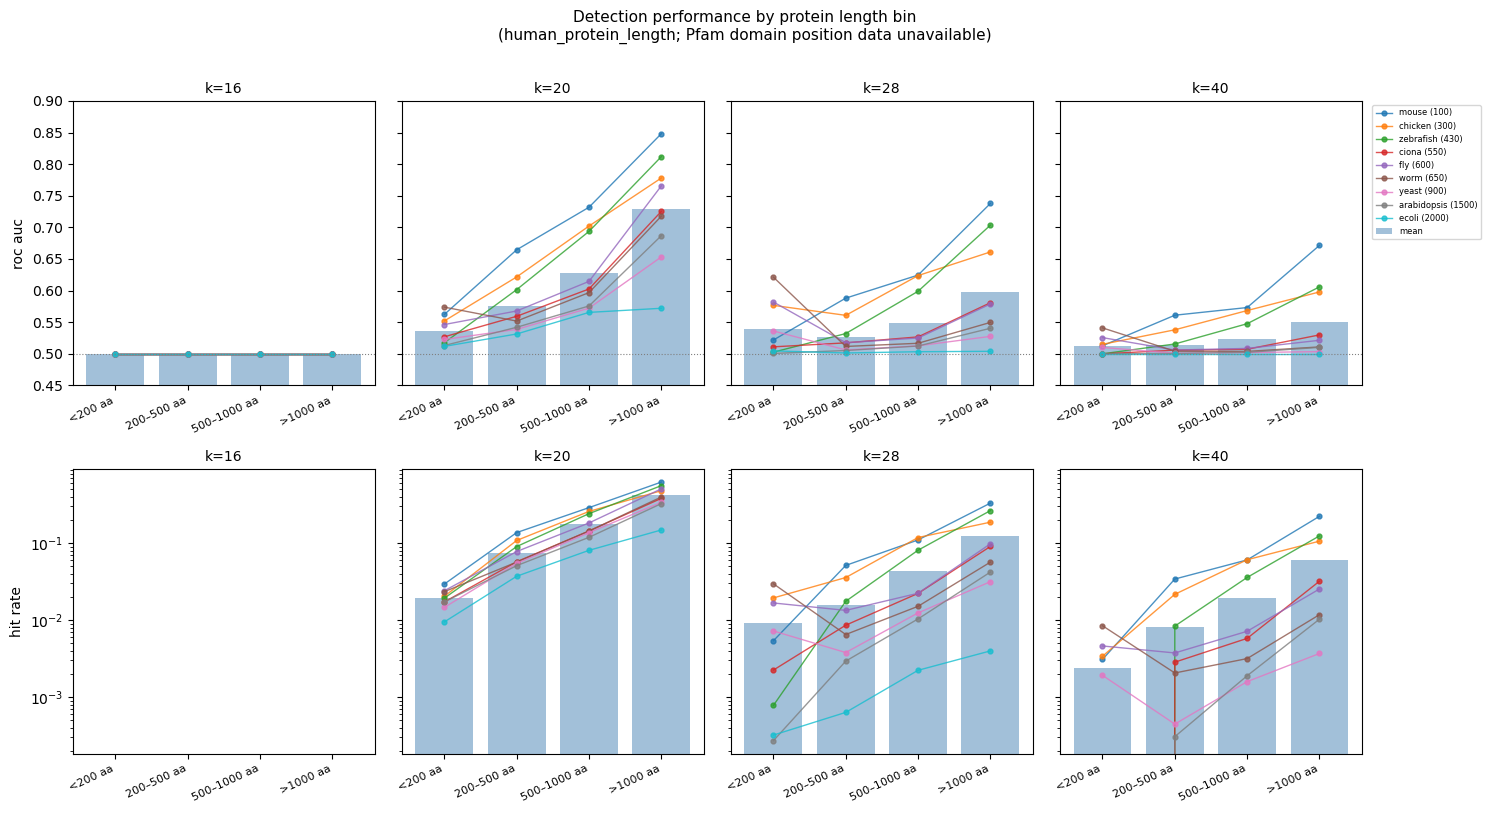

In [23]:
# Plot AUC and hit rate by protein length bin, faceted by k-size
fig, axes = plt.subplots(2, 4, figsize=(15, 8), sharey="row")

for col_idx, ksize in enumerate([16, 20, 28, 40]):
    sub_k = domain_df.filter(pl.col("ksize") == ksize)

    for row_idx, metric in enumerate(["roc_auc", "hit_rate"]):
        ax = axes[row_idx, col_idx]

        means = [
            (
                sub_k.filter(pl.col("domain_bin") == b)[metric].mean()
                if b in sub_k["domain_bin"].to_list()
                else np.nan
            )
            for b in BIN_ORDER
        ]
        x = np.arange(len(BIN_ORDER))
        ax.bar(x, means, color="steelblue", alpha=0.5, label="mean")

        for sp, color in zip(SPECIES_ORDER, sp_colors):
            sp_vals = [
                (
                    sub_k.filter(
                        (pl.col("species") == sp) & (pl.col("domain_bin") == b)
                    )[metric].item()
                    if not sub_k.filter(
                        (pl.col("species") == sp) & (pl.col("domain_bin") == b)
                    ).is_empty()
                    else np.nan
                )
                for b in BIN_ORDER
            ]
            ax.plot(
                x,
                sp_vals,
                "o-",
                color=color,
                markersize=3.5,
                linewidth=1,
                label=f"{sp} ({META[sp]['mya']})",
                alpha=0.8,
            )

        if metric == "roc_auc":
            ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.8)
            ax.set_ylim(0.45, 0.90)
        else:
            ax.set_yscale("log")

        ax.set_xticks(x)
        ax.set_xticklabels(BIN_ORDER, rotation=25, ha="right", fontsize=8)
        ax.set_title(f"k={ksize}", fontsize=10)
        if col_idx == 0:
            ax.set_ylabel(metric.replace("_", " "), fontsize=10)
        if col_idx == 3 and row_idx == 0:
            ax.legend(fontsize=6, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.suptitle(
    "Detection performance by protein length bin\n"
    "(human_protein_length; Pfam domain position data unavailable)",
    fontsize=11,
    y=1.01,
)
plt.tight_layout()
plt.savefig(
    "../figures/126_protein_length_stratified_auc.png", dpi=150, bbox_inches="tight"
)
plt.show()

---
## Section 4: ML Classifier — Can We Beat the Best Composite Score?

**Design**: Leave-one-species-out cross-validation at k=20.  
**Features**: 7 raw k-mer metrics (no p-value — it may be mis-calibrated).  
**Models**: Logistic Regression (L2) and Gradient Boosted Trees.  
**Baseline**: `score_enr_cont_freq` AUC on the same test set.

In [24]:
ML_FEATURES = [
    "enrichment",
    "containment",
    "jaccard",
    "query_tfidf",
    "mean_matched_kmer_freq",
    "sum_matched_kmer_freq",
    "expected_shared_kmers",
]
KSIZE_ML = 20

frames = [
    all_merged[(sp, KSIZE_ML)].select(["label", "species"] + ML_FEATURES)
    for sp in SPECIES_ORDER
    if (sp, KSIZE_ML) in all_merged
]
all_data = pl.concat(frames)
print(f"Total pairs: {len(all_data):,}")
print(
    f'Class balance: {int(all_data["label"].sum()):,} positives ({100*all_data["label"].mean():.1f}%)'
)

Total pairs: 591,383
Class balance: 227,580 positives (38.5%)


In [25]:
ml_results = []

for test_sp in SPECIES_ORDER:
    if (test_sp, KSIZE_ML) not in all_merged:
        continue
    train = all_data.filter(pl.col("species") != test_sp)
    test = all_data.filter(pl.col("species") == test_sp)

    X_train = train.select(ML_FEATURES).fill_null(0).fill_nan(0).to_numpy()
    y_train = train["label"].cast(pl.Int8).to_numpy()
    X_test = test.select(ML_FEATURES).fill_null(0).fill_nan(0).to_numpy()
    y_test = test["label"].cast(pl.Int8).to_numpy()

    baseline_scores = (
        all_merged[(test_sp, KSIZE_ML)][BEST_SCORE].fill_null(0).fill_nan(0).to_numpy()
    )
    baseline_auc = roc_auc_score(y_test, baseline_scores)

    for model_name, clf in [
        (
            "LR (L2)",
            Pipeline(
                [
                    ("scaler", StandardScaler()),
                    ("clf", LogisticRegression(max_iter=500, C=1.0)),
                ]
            ),
        ),
        (
            "GBT",
            GradientBoostingClassifier(
                n_estimators=100, max_depth=3, learning_rate=0.1, subsample=0.5
            ),
        ),
    ]:
        clf.fit(X_train, y_train)
        proba = clf.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, proba)
        ml_results.append(
            {
                "species": test_sp,
                "mya": META[test_sp]["mya"],
                "model": model_name,
                "roc_auc": auc,
                "baseline_roc_auc": baseline_auc,
                "delta": auc - baseline_auc,
            }
        )
        print(
            f"  {test_sp:12} {model_name:10}  AUC={auc:.4f}  baseline={baseline_auc:.4f}  Δ={auc-baseline_auc:+.4f}"
        )

ml_df = pl.DataFrame(ml_results)
print("\nMean AUC by model:")
print(
    ml_df.group_by("model").agg(
        [
            pl.col("roc_auc").mean().alias("mean_auc"),
            pl.col("baseline_roc_auc").mean().alias("mean_baseline"),
            pl.col("delta").mean().alias("mean_delta"),
        ]
    )
)

  mouse        LR (L2)     AUC=0.7698  baseline=0.7673  Δ=+0.0025
  mouse        GBT         AUC=0.7707  baseline=0.7673  Δ=+0.0034
  chicken      LR (L2)     AUC=0.7106  baseline=0.7097  Δ=+0.0008
  chicken      GBT         AUC=0.7120  baseline=0.7097  Δ=+0.0023
  zebrafish    LR (L2)     AUC=0.7238  baseline=0.7221  Δ=+0.0017
  zebrafish    GBT         AUC=0.7241  baseline=0.7221  Δ=+0.0019
  ciona        LR (L2)     AUC=0.6456  baseline=0.6439  Δ=+0.0017
  ciona        GBT         AUC=0.6462  baseline=0.6439  Δ=+0.0023
  fly          LR (L2)     AUC=0.6715  baseline=0.6684  Δ=+0.0031
  fly          GBT         AUC=0.6750  baseline=0.6684  Δ=+0.0067
  worm         LR (L2)     AUC=0.6376  baseline=0.6358  Δ=+0.0018
  worm         GBT         AUC=0.6395  baseline=0.6358  Δ=+0.0038
  yeast        LR (L2)     AUC=0.6004  baseline=0.5989  Δ=+0.0015
  yeast        GBT         AUC=0.6026  baseline=0.5989  Δ=+0.0037
  arabidopsis  LR (L2)     AUC=0.6049  baseline=0.6035  Δ=+0.0014
  arabidop

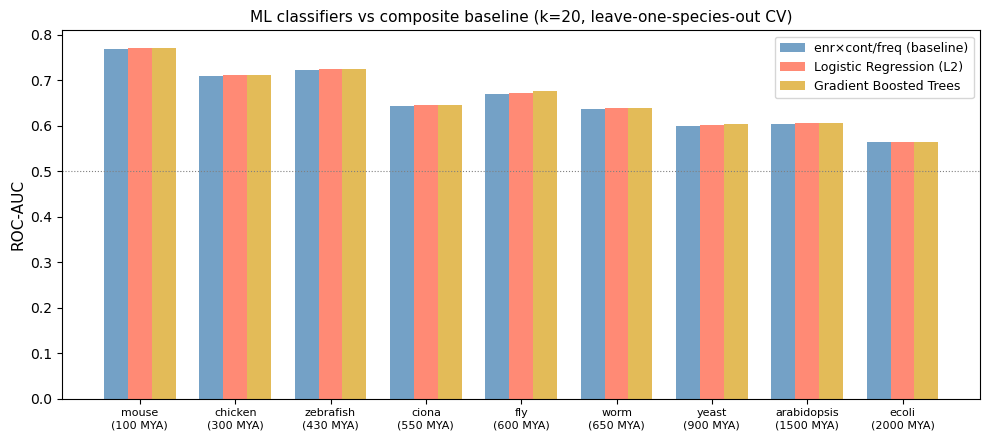

In [26]:
# Plot ML vs baseline
sp_ml = sorted(set(r["species"] for r in ml_results), key=lambda s: META[s]["mya"])
x = np.arange(len(sp_ml))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(
    x - width,
    [
        next(
            r["baseline_roc_auc"]
            for r in ml_results
            if r["species"] == sp and r["model"] == "LR (L2)"
        )
        for sp in sp_ml
    ],
    width,
    label="enr×cont/freq (baseline)",
    color="steelblue",
    alpha=0.75,
)
ax.bar(
    x,
    [
        next(
            r["roc_auc"]
            for r in ml_results
            if r["species"] == sp and r["model"] == "LR (L2)"
        )
        for sp in sp_ml
    ],
    width,
    label="Logistic Regression (L2)",
    color="tomato",
    alpha=0.75,
)
ax.bar(
    x + width,
    [
        next(
            r["roc_auc"]
            for r in ml_results
            if r["species"] == sp and r["model"] == "GBT"
        )
        for sp in sp_ml
    ],
    width,
    label="Gradient Boosted Trees",
    color="goldenrod",
    alpha=0.75,
)

ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"{sp}\n({META[sp]['mya']} MYA)" for sp in sp_ml], fontsize=8)
ax.set_ylabel("ROC-AUC", fontsize=11)
ax.set_title(
    f"ML classifiers vs composite baseline (k={KSIZE_ML}, leave-one-species-out CV)",
    fontsize=11,
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../figures/126_ml_classifier_auc.png", dpi=150, bbox_inches="tight")
plt.show()

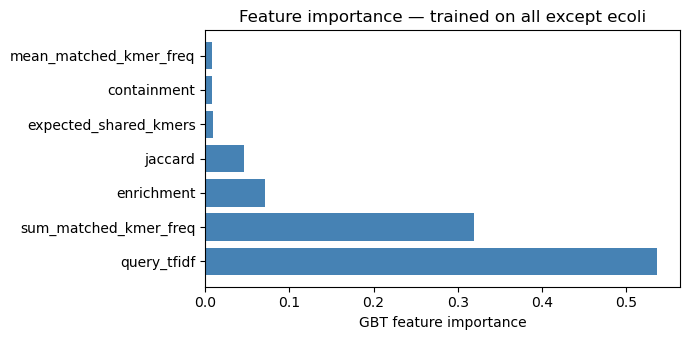

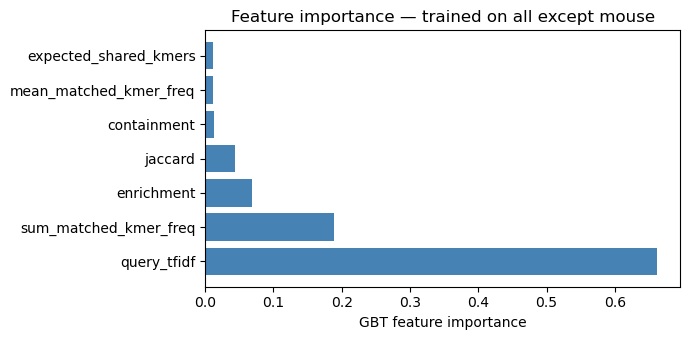

In [27]:
# Feature importance from GBT (train on all except ecoli to test on ecoli — most distant)
for held_out in ["ecoli", "mouse"]:
    train_data = all_data.filter(pl.col("species") != held_out)
    X_tr = train_data.select(ML_FEATURES).fill_null(0).fill_nan(0).to_numpy()
    y_tr = train_data["label"].cast(pl.Int8).to_numpy()
    gbt = GradientBoostingClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1, subsample=0.5
    )
    gbt.fit(X_tr, y_tr)

    order = np.argsort(gbt.feature_importances_)[::-1]
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.barh(
        [ML_FEATURES[i] for i in order],
        gbt.feature_importances_[order],
        color="steelblue",
    )
    ax.set_xlabel("GBT feature importance")
    ax.set_title(f"Feature importance — trained on all except {held_out}")
    plt.tight_layout()
    plt.savefig(
        f"../figures/126_gbt_feature_importance_{held_out}.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

---
## Section 5: Operational Thresholds

**Question**: What `score_enr_cont_freq` cutoffs achieve ≥99% precision or ≥80% recall per species × k-size?

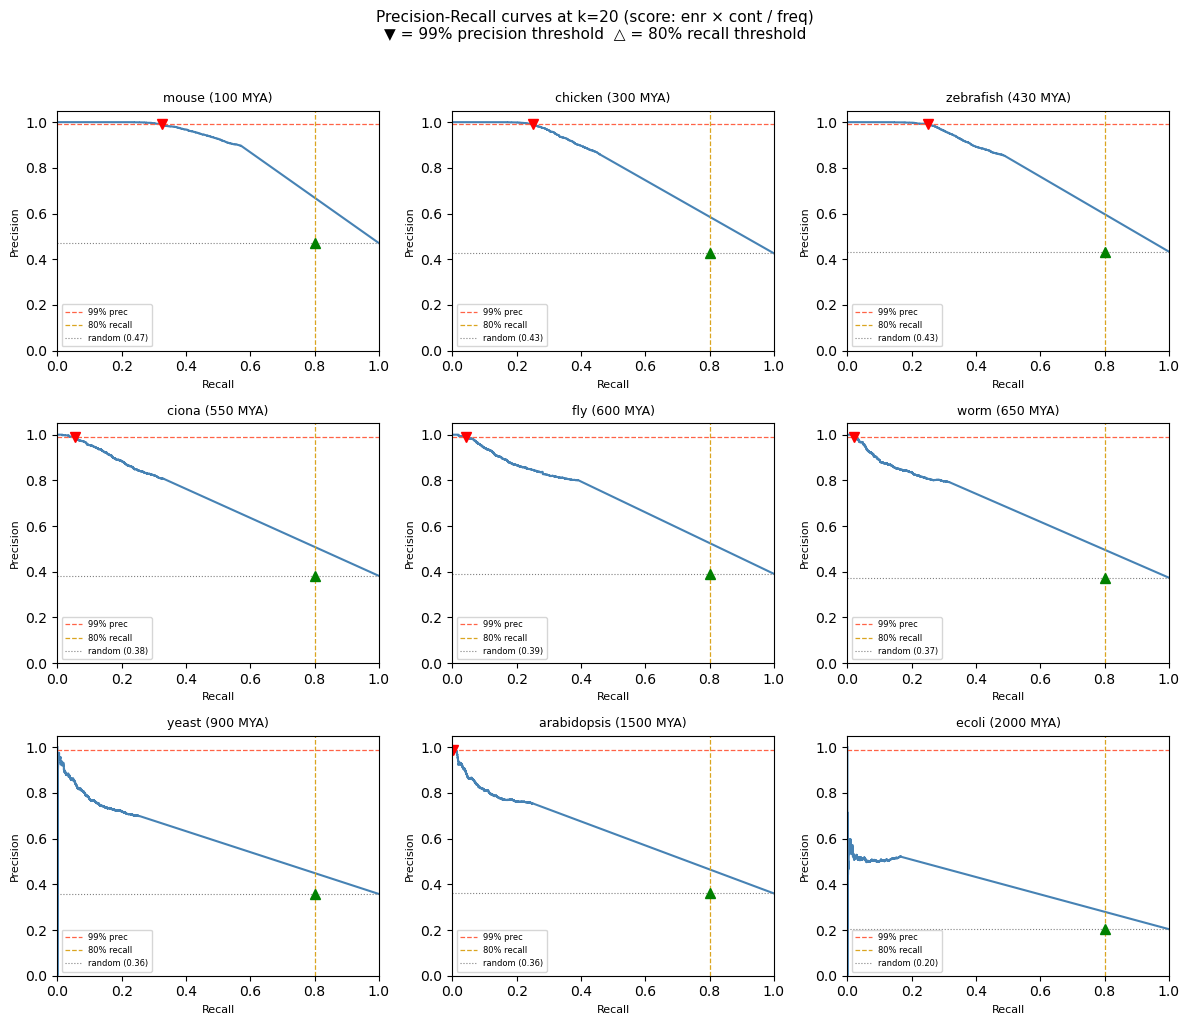


Operational thresholds at k=20:
shape: (9, 7)
┌─────────────┬──────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────────┐
│ species     ┆ mya  ┆ baseline_prec ┆ thresh_99pct_ ┆ recall_at_99p ┆ thresh_80pct ┆ precision_at │
│ ---         ┆ ---  ┆ ision         ┆ prec          ┆ ct_prec       ┆ _recall      ┆ _80pct_recal │
│ str         ┆ i64  ┆ ---           ┆ ---           ┆ ---           ┆ ---          ┆ l            │
│             ┆      ┆ f64           ┆ f64           ┆ f64           ┆ f64          ┆ ---          │
│             ┆      ┆               ┆               ┆               ┆              ┆ f64          │
╞═════════════╪══════╪═══════════════╪═══════════════╪═══════════════╪══════════════╪══════════════╡
│ mouse       ┆ 100  ┆ 0.471         ┆ 2931.79       ┆ 0.325         ┆ 0.0          ┆ 0.471        │
│ chicken     ┆ 300  ┆ 0.426         ┆ 3055.17       ┆ 0.251         ┆ 0.0          ┆ 0.426        │
│ zebrafish   ┆ 430  ┆ 0.433         ┆ 4521.

In [28]:
# PR curves at k=20 for all species
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes_flat = axes.flatten()
thresh_rows = []

for ax, sp in zip(axes_flat, SPECIES_ORDER):
    key = (sp, 20)
    if key not in all_merged:
        ax.set_visible(False)
        continue
    df = all_merged[key]
    y = df["label"].cast(pl.Int8).to_numpy()
    scores = df[BEST_SCORE].fill_null(0).fill_nan(0).to_numpy()
    baseline_prec = float(y.mean())

    prec, rec, thresholds = precision_recall_curve(y, scores)

    mask99 = prec[:-1] >= 0.99
    thresh99 = float(thresholds[mask99].min()) if mask99.any() else float("nan")
    recall_at_99 = float(rec[:-1][mask99].max()) if mask99.any() else 0.0

    mask80 = rec[:-1] >= 0.80
    thresh80 = float(thresholds[mask80].max()) if mask80.any() else float("nan")
    prec_at_80 = float(prec[:-1][mask80].max()) if mask80.any() else 0.0

    thresh_rows.append(
        {
            "species": sp,
            "mya": META[sp]["mya"],
            "baseline_precision": round(baseline_prec, 3),
            "thresh_99pct_prec": round(thresh99, 2) if not np.isnan(thresh99) else None,
            "recall_at_99pct_prec": round(recall_at_99, 3),
            "thresh_80pct_recall": (
                round(thresh80, 2) if not np.isnan(thresh80) else None
            ),
            "precision_at_80pct_recall": round(prec_at_80, 3),
        }
    )

    ax.plot(rec, prec, linewidth=1.5, color="steelblue")
    ax.axhline(0.99, color="tomato", linestyle="--", linewidth=0.9, label="99% prec")
    ax.axvline(
        0.80, color="goldenrod", linestyle="--", linewidth=0.9, label="80% recall"
    )
    ax.axhline(
        baseline_prec,
        color="gray",
        linestyle=":",
        linewidth=0.8,
        label=f"random ({baseline_prec:.2f})",
    )
    if not np.isnan(thresh99):
        ax.plot(recall_at_99, 0.99, "rv", markersize=7)
    if not np.isnan(thresh80):
        ax.plot(0.80, prec_at_80, "g^", markersize=7)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Recall", fontsize=8)
    ax.set_ylabel("Precision", fontsize=8)
    ax.set_title(f"{sp} ({META[sp]['mya']} MYA)", fontsize=9)
    ax.legend(fontsize=6)

plt.suptitle(
    "Precision-Recall curves at k=20 (score: enr × cont / freq)\n"
    "▼ = 99% precision threshold  △ = 80% recall threshold",
    y=1.02,
    fontsize=11,
)
plt.tight_layout()
plt.savefig("../figures/126_precision_recall_curves.png", dpi=150, bbox_inches="tight")
plt.show()

thresh_df = pl.DataFrame(thresh_rows).sort("mya")
print("\nOperational thresholds at k=20:")
print(thresh_df)

In [29]:
# Recall at 99% precision for all k-sizes × species — pivot table for SAB
thresh_ksize_rows = []

for (sp, ksize), df in all_merged.items():
    y = df["label"].cast(pl.Int8).to_numpy()
    scores = df[BEST_SCORE].fill_null(0).fill_nan(0).to_numpy()
    if y.sum() == 0:
        continue
    prec, rec, thresholds = precision_recall_curve(y, scores)

    mask99 = prec[:-1] >= 0.99
    recall99 = float(rec[:-1][mask99].max()) if mask99.any() else 0.0

    mask80 = rec[:-1] >= 0.80
    prec80 = float(prec[:-1][mask80].max()) if mask80.any() else 0.0

    thresh_ksize_rows.append(
        {
            "species": sp,
            "mya": META[sp]["mya"],
            "ksize": ksize,
            "recall_at_99pct_prec": round(recall99, 3),
            "prec_at_80pct_recall": round(prec80, 3),
        }
    )

tkdf = pl.DataFrame(thresh_ksize_rows).sort(["mya", "ksize"])
tkdf.write_csv(BENCHMARK_DIR / "merged/126_operational_thresholds.csv")

print("Recall @ 99% precision by species × ksize:")
print(
    tkdf.pivot(
        on="ksize", index=["species", "mya"], values="recall_at_99pct_prec"
    ).sort("mya")
)
print("\nPrecision @ 80% recall by species × ksize:")
print(
    tkdf.pivot(
        on="ksize", index=["species", "mya"], values="prec_at_80pct_recall"
    ).sort("mya")
)

Recall @ 99% precision by species × ksize:
shape: (9, 12)
┌─────────────┬──────┬─────┬─────┬───┬───────┬───────┬───────┬───────┐
│ species     ┆ mya  ┆ 12  ┆ 14  ┆ … ┆ 28    ┆ 32    ┆ 36    ┆ 40    │
│ ---         ┆ ---  ┆ --- ┆ --- ┆   ┆ ---   ┆ ---   ┆ ---   ┆ ---   │
│ str         ┆ i64  ┆ f64 ┆ f64 ┆   ┆ f64   ┆ f64   ┆ f64   ┆ f64   │
╞═════════════╪══════╪═════╪═════╪═══╪═══════╪═══════╪═══════╪═══════╡
│ mouse       ┆ 100  ┆ 0.0 ┆ 0.0 ┆ … ┆ 0.308 ┆ 0.258 ┆ 0.228 ┆ 0.202 │
│ chicken     ┆ 300  ┆ 0.0 ┆ 0.0 ┆ … ┆ 0.231 ┆ 0.177 ┆ 0.155 ┆ 0.131 │
│ zebrafish   ┆ 430  ┆ 0.0 ┆ 0.0 ┆ … ┆ 0.231 ┆ 0.179 ┆ 0.139 ┆ 0.109 │
│ ciona       ┆ 550  ┆ 0.0 ┆ 0.0 ┆ … ┆ 0.083 ┆ 0.054 ┆ 0.037 ┆ 0.027 │
│ fly         ┆ 600  ┆ 0.0 ┆ 0.0 ┆ … ┆ 0.076 ┆ 0.046 ┆ 0.08  ┆ 0.022 │
│ worm        ┆ 650  ┆ 0.0 ┆ 0.0 ┆ … ┆ 0.052 ┆ 0.031 ┆ 0.026 ┆ 0.014 │
│ yeast       ┆ 900  ┆ 0.0 ┆ 0.0 ┆ … ┆ 0.022 ┆ 0.013 ┆ 0.015 ┆ 0.005 │
│ arabidopsis ┆ 1500 ┆ 0.0 ┆ 0.0 ┆ … ┆ 0.027 ┆ 0.017 ┆ 0.01  ┆ 0.007 │
│ ecoli       ┆ 200

---
## SAB Summary Table

Fill in after running the notebook above.

In [30]:
# Auto-generate SAB summary from computed results
print("=== SAB SUMMARY ===")
print()

# 1. Effective window
print("1. EFFECTIVE K-SIZE WINDOW")
print(best_k_df.to_pandas().to_string(index=False))
print()

# 2. Bonferroni collapse
bonf20 = bonf_df.filter(pl.col("ksize") == 20).sort("mya")
print("2. BONFERRONI COLLAPSE AT K=20 (fraction of TPs with score=0):")
print(
    bonf20.select(["species", "mya", "n_bonf", "frac_tp_lost"])
    .to_pandas()
    .to_string(index=False)
)
print()

# 3. Best scoring method at k=20 (mean over species)
print("3. MEAN ROC-AUC BY SCORING METHOD AT K=20:")
mean_auc_by_score = (
    auc_df.filter(pl.col("ksize") == 20)
    .group_by("score_col")
    .agg(pl.col("roc_auc").mean().alias("mean_roc_auc"))
    .sort("mean_roc_auc", descending=True)
)
print(mean_auc_by_score.to_pandas().to_string(index=False))
print()

# 4. ML improvement
print("4. ML IMPROVEMENT OVER BASELINE:")
print(
    ml_df.group_by("model")
    .agg(
        [
            pl.col("roc_auc").mean().round(4).alias("mean_auc"),
            pl.col("baseline_roc_auc").mean().round(4).alias("mean_baseline"),
            pl.col("delta").mean().round(4).alias("mean_delta"),
        ]
    )
    .to_pandas()
    .to_string(index=False)
)
print()

# 5. Thresholds
print("5. OPERATIONAL THRESHOLDS AT K=20:")
print(thresh_df.to_pandas().to_string(index=False))

=== SAB SUMMARY ===

1. EFFECTIVE K-SIZE WINDOW
    species  mya  best_ksize  best_roc_auc  k20_roc_auc  improvement_over_k20
      mouse  100          20        0.7673       0.7673                   0.0
    chicken  300          20        0.7097       0.7097                   0.0
  zebrafish  430          20        0.7221       0.7221                   0.0
      ciona  550          20        0.6439       0.6439                   0.0
        fly  600          20        0.6684       0.6684                   0.0
       worm  650          20        0.6358       0.6358                   0.0
      yeast  900          20        0.5989       0.5989                   0.0
arabidopsis 1500          20        0.6035       0.6035                   0.0
      ecoli 2000          20        0.5632       0.5632                   0.0

2. BONFERRONI COLLAPSE AT K=20 (fraction of TPs with score=0):
    species  mya    n_bonf  frac_tp_lost
      mouse  100 452973400      0.640340
    chicken  300 373189600